## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.
2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.
3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?
4. What difficulties did you encounter in obtaining the data?
5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [1]:
import ast
import json
import os
import re
from collections import Counter

import ijson
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from transformers import AutoModelForCausalLM, AutoTokenizer

USE_CUDA = torch.cuda.is_available()
if USE_CUDA:
    print(f"CUDA available: using GPU ({torch.cuda.get_device_name(0)})")

# Paths: ToolBench toolllama preprocessed data (instruction + structured API list)
DATA_DIR = "data"
TRAIN_PATH = os.path.join(DATA_DIR, "toolllama_G123_dfs_train.json")
EVAL_PATH = os.path.join(DATA_DIR, "toolllama_G123_dfs_eval.json")
OUTPUT_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Subsampling: set to None to load full data; use integers for faster runs
MAX_TRAIN_SAMPLES = 20000
MAX_EVAL_SAMPLES = None

def load_toolbench_json(path, max_items=None):
    """Load one toolllama JSON file and return the list of items.
    If max_items is set, only the first max_items are loaded (faster when subsampling).
    """
    if max_items is None:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    # Stream first N items with ijson to avoid parsing the whole file (much faster).
    items = []
    with open(path, "rb") as f:
        for obj in ijson.items(f, "item"):
            items.append(obj)
            if len(items) >= max_items:
                break
    return items

def extract_instruction(conversations):
    """Modality 1: natural language instruction from first user message."""
    for msg in conversations:
        if msg.get("from") == "user":
            raw = msg.get("value", "").strip()
            return raw.replace("\nBegin!\n", "").strip() if raw else ""
    return ""

def extract_api_list_text(conversations):
    """Modality 2: structured toolset (API list) from first system message."""
    for msg in conversations:
        if msg.get("from") == "system":
            return msg.get("value", "")
    return ""

def parse_api_names_from_system(system_text):
    """Parse API names from 'Specifically, you have access to the following APIs: [...]'."""
    match = re.search(r"Specifically, you have access to the following APIs:\s*(\[.+\])", system_text, re.DOTALL)
    if not match:
        return []
    try:
        # The list uses single quotes; ast.literal_eval needs double quotes for JSON-like parsing
        s = match.group(1).replace("'", '"')
        api_list = ast.literal_eval(s) if s else []
        return [api.get("name", "") for api in api_list if isinstance(api, dict) and api.get("name") != "Finish"]
    except Exception:
        return []

def extract_function_calls_used(conversations):
    """Extract API names actually called from assistant Action turns (for evaluation)."""
    called = []
    for msg in conversations:
        if msg.get("from") != "assistant":
            continue
        value = msg.get("value", "")
        if "Action:" in value:
            lines = value.split("\n")
            for line in lines:
                if line.strip().startswith("Action:"):
                    action_name = line.split("Action:")[-1].strip()
                    if action_name and action_name != "Finish":
                        called.append(action_name)
    return list(dict.fromkeys(called))  # preserve order, no duplicates

def parse_api_list_structured(system_text):
    """Extract the structured API list (list of dicts with name, description, parameters) from system message.
    Returns the actual JSON-serializable list, not the full LLaMA prompt."""
    match = re.search(r"Specifically, you have access to the following APIs:\s*(\[.+\])", system_text, re.DOTALL)
    if not match:
        return []
    try:
        api_list = ast.literal_eval(match.group(1))
        if not isinstance(api_list, list):
            return []
        out = []
        for api in api_list:
            if isinstance(api, dict) and api.get("name") != "Finish":
                out.append({k: api[k] for k in ("name", "description", "parameters") if k in api})
        return out
    except Exception:
        return []

def extract_reasoning_output(conversations):
    """Modality 3: reasoning = all Thought text from assistant messages (unstructured)."""
    parts = []
    for msg in conversations:
        if msg.get("from") != "assistant":
            continue
        value = msg.get("value", "")
        # Extract text after each "Thought:" up to (not including) "Action:"
        for m in re.finditer(r"Thought:\s*(.*?)(?=\s*Action:|\Z)", value, re.DOTALL):
            t = m.group(1).strip()
            if t:
                parts.append(t)
    return "\n\n".join(parts) if parts else ""

def extract_function_calls_output(conversations):
    """Modality 4: function calls = list of {name, arguments} from Action/Action Input (structured)."""
    out = []
    for msg in conversations:
        if msg.get("from") != "assistant":
            continue
        value = msg.get("value", "")
        # Match "Action: <name>" then "Action Input: <content>" (content to next Thought/Action or end)
        for m in re.finditer(r"Action:\s*(.+?)\s*Action Input:\s*(.*?)(?=\nThought:|\nAction:|\Z)", value, re.DOTALL):
            name = m.group(1).strip()
            args = m.group(2).strip()
            if name and name != "Finish":
                out.append({"name": name, "arguments": args})
    return out

def extract_items_to_rows(data):
    """Extract all four modalities from a list of toolllama items (no train/eval split)."""
    rows = []
    for item in data:
        conv = item.get("conversations", [])
        instruction = extract_instruction(conv)
        api_list_text = extract_api_list_text(conv)
        api_list_structured = parse_api_list_structured(api_list_text)
        api_names = [a.get("name", "") for a in api_list_structured if a.get("name")]
        function_calls_list = extract_function_calls_output(conv)
        function_calls_used = extract_function_calls_used(conv)
        reasoning_output = extract_reasoning_output(conv)
        rows.append({
            "id": item.get("id", ""),
            "instruction": instruction,
            "api_list_text": api_list_text[:5000] if len(api_list_text) > 5000 else api_list_text,
            "api_list_json": json.dumps(api_list_structured) if api_list_structured else "[]",
            "num_apis": len(api_names),
            "tool_names": "|".join(api_names[:20]),
            "function_calls_used": "|".join(function_calls_used[:15]),
            "reasoning_output": reasoning_output,
            "function_calls_json": json.dumps(function_calls_list) if function_calls_list else "[]",
        })
    return rows

# Load dataset: merge train + eval into one
train_items = load_toolbench_json(TRAIN_PATH, max_items=MAX_TRAIN_SAMPLES)
eval_items = load_toolbench_json(EVAL_PATH, max_items=MAX_EVAL_SAMPLES)
all_items = train_items + eval_items
rows = extract_items_to_rows(all_items)
df_toolbench = pd.DataFrame(rows)
out_path = os.path.join(OUTPUT_DIR, "toolbench_modalities.csv")
df_toolbench.to_csv(out_path, index=False)
if MAX_TRAIN_SAMPLES is not None or MAX_EVAL_SAMPLES is not None:
    print(f"Subsampled: {len(all_items)} total (train={len(train_items)}, eval={len(eval_items)}). Set MAX_*_SAMPLES=None for full data.")
print(f"Extracted {len(df_toolbench)} instances. Columns: {list(df_toolbench.columns)}")
print(f"Saved to {out_path}")
df_toolbench.head(2)

/home/arthurdls/anaconda3/envs/multimodal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: using GPU (NVIDIA GeForce RTX 3060 Laptop GPU)
Subsampled: 20762 total (train=20000, eval=762). Set MAX_*_SAMPLES=None for full data.
Extracted 20762 instances. Columns: ['id', 'instruction', 'api_list_text', 'api_list_json', 'num_apis', 'tool_names', 'function_calls_used', 'reasoning_output', 'function_calls_json']
Saved to data/processed/toolbench_modalities.csv


,id,instruction,api_list_text,api_list_json,num_apis,tool_names,function_calls_used,reasoning_output,function_calls_json
0,Step 7: I'm conducting a research project on s...,I'm conducting a research project on social me...,"You are AutoGPT, you can use many tools(functi...","[{""name"": ""userinfo_for_instagram_cheapest"", ""...",2,userinfo_for_instagram_cheapest|user_medias_fo...,userinfo_for_instagram_cheapest|user_medias_fo...,I need to gather user information for a specif...,"[{""name"": ""userinfo_for_instagram_cheapest"", ""..."
1,Step 3: I want to surprise my friends with a b...,I want to surprise my friends with a beer tast...,"You are AutoGPT, you can use many tools(functi...","[{""name"": ""search_for_open_brewery_db"", ""descr...",9,search_for_open_brewery_db|breweries_for_open_...,search_for_open_brewery_db,"Based on the previous action candidates, it se...","[{""name"": ""search_for_open_brewery_db"", ""argum..."


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [2]:
# Modality colors and names (consistent across all plots)
MODALITY_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # instruction, API list, reasoning, function calls
MODALITY_NAMES = ["Instruction", "API list", "Reasoning", "Function calls"]

def visualize_data_distribution(data, x_feature="t-SNE dimension 1", y_feature="t-SNE dimension 2",
                                num_components=2, perplexity=30, num_iterations=1000, title=None, color=None):
  """
  Visualizes the distribution of data using t-SNE and a 2D scatter plot.
  If color is provided (e.g. MODALITY_COLORS[i]), scatter uses that color. title sets the plot title.
  """
  tsne = TSNE(n_components=num_components, perplexity=perplexity, max_iter=num_iterations, random_state=42)
  tsne_data = tsne.fit_transform(data)

  plt.figure(figsize=(10, 6))
  scatter_color = color if color is not None else "C0"
  plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=scatter_color, alpha=0.5, s=10)
  plt.title(title if title is not None else "Data distribution (t-SNE)")
  plt.xlabel(x_feature)
  plt.ylabel(y_feature)
  plt.tight_layout()
  plt.show()



In [3]:
# Reduce dimension before t-SNE: use GPU (PyTorch) if CUDA available, else CPU (sklearn)
def pca_reduce(X, n_components=50, random_state=42):
    if X.shape[1] <= n_components:
        return X
    if USE_CUDA:
        torch.manual_seed(random_state)
        X_t = torch.from_numpy(X).float().to("cuda")
        X_centered = X_t - X_t.mean(dim=0)
        U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)
        X_reduced = (U[:, :n_components] * S[:n_components]).cpu().numpy()
        return X_reduced
    pca = PCA(n_components=n_components, random_state=random_state)
    return pca.fit_transform(X)


## Four modalities visualized

(1) Instruction (unstructured input), (2) API list (structured input), (3) Reasoning (unstructured output), (4) Function calls (structured output). Colors are consistent per modality.

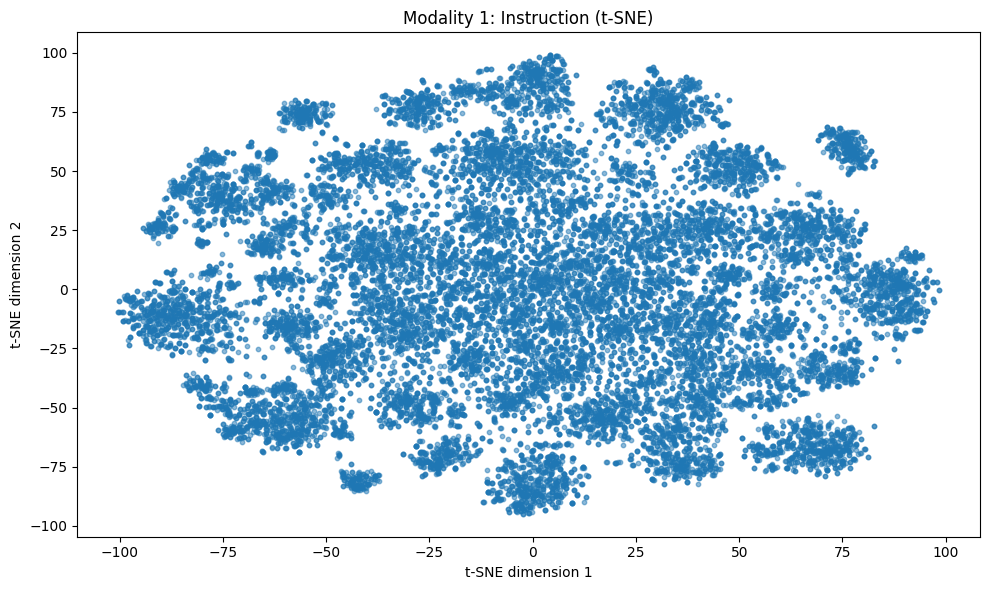

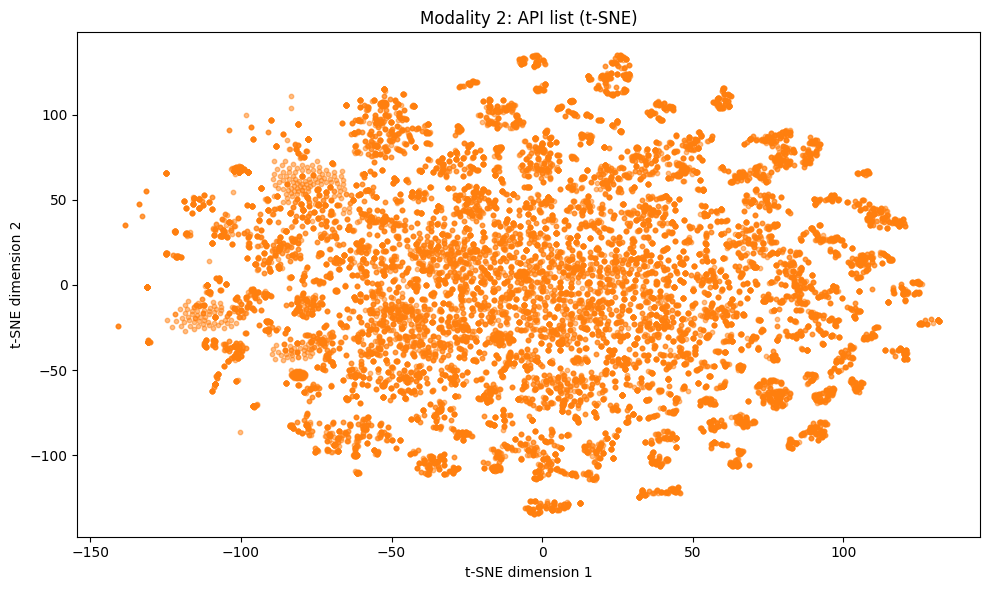

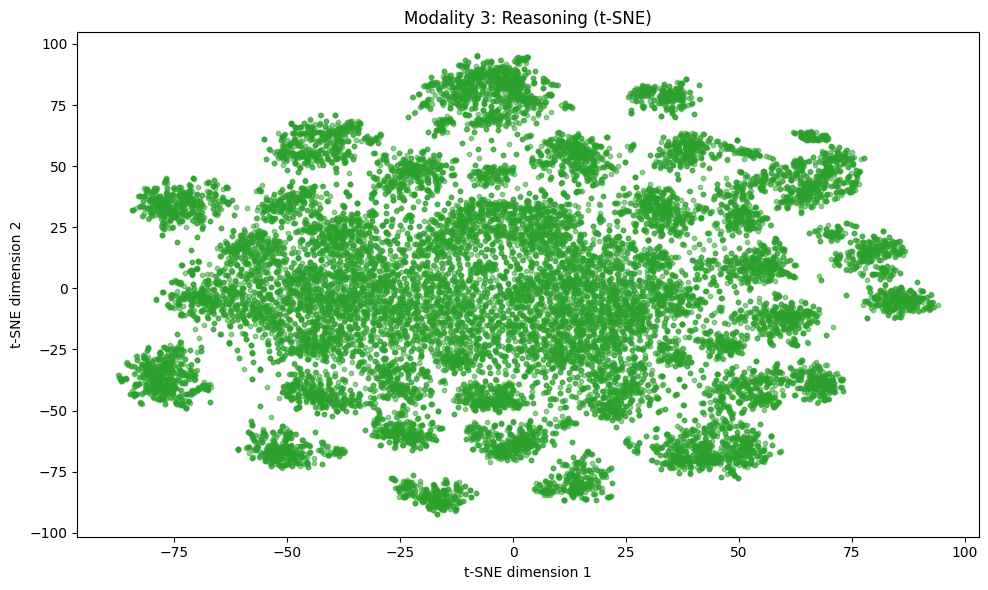

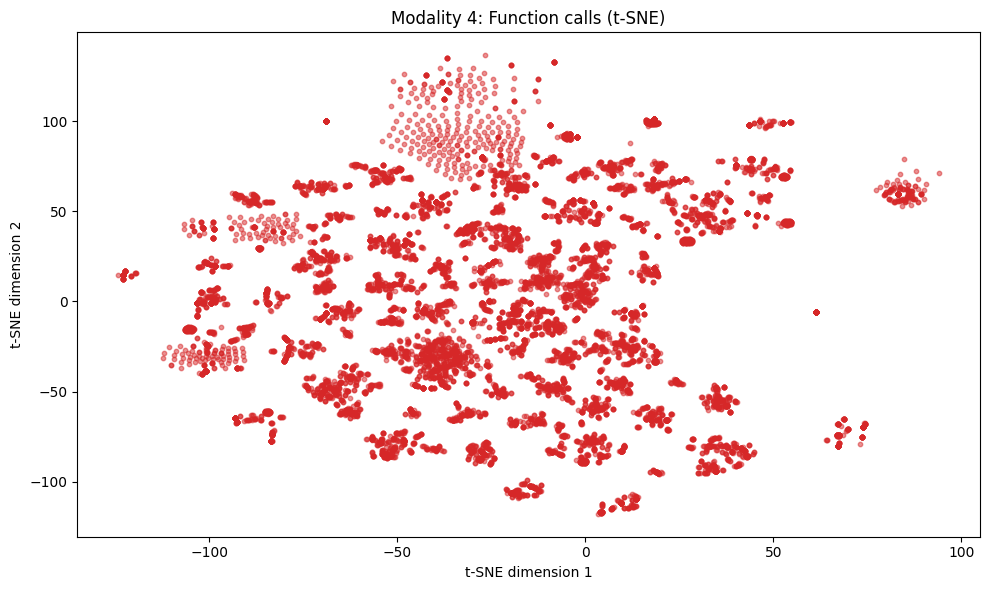

In [4]:
# Run extraction cell first so df_toolbench has api_list_json, reasoning_output, function_calls_json.
df = df_toolbench.copy()
df["instruction"] = df["instruction"].fillna("")
df["api_list_json"] = df["api_list_json"].fillna("[]")
df["reasoning_output"] = df["reasoning_output"].fillna("")
df["function_calls_json"] = df["function_calls_json"].fillna("[]")

vectorizer = TfidfVectorizer(max_features=200, stop_words="english", ngram_range=(1, 2))

# Modality 1: Instruction (unstructured input)
X1 = vectorizer.fit_transform(df["instruction"]).toarray()
X1_reduced = pca_reduce(X1, n_components=50)
visualize_data_distribution(X1_reduced, perplexity=30, num_iterations=1000,
                            title="Modality 1: Instruction (t-SNE)", color=MODALITY_COLORS[0])

# Modality 2: API list (structured input)
X2 = vectorizer.fit_transform(df["api_list_json"].astype(str)).toarray()
X2_reduced = pca_reduce(X2, n_components=50)
visualize_data_distribution(X2_reduced, perplexity=30, num_iterations=1000,
                            title="Modality 2: API list (t-SNE)", color=MODALITY_COLORS[1])

# Modality 3: Reasoning (unstructured output)
X3 = vectorizer.fit_transform(df["reasoning_output"]).toarray()
X3_reduced = pca_reduce(X3, n_components=50)
visualize_data_distribution(X3_reduced, perplexity=30, num_iterations=1000,
                            title="Modality 3: Reasoning (t-SNE)", color=MODALITY_COLORS[2])

# Modality 4: Function calls (structured output)
X4 = vectorizer.fit_transform(df["function_calls_json"].astype(str)).toarray()
X4_reduced = pca_reduce(X4, n_components=50)
visualize_data_distribution(X4_reduced, perplexity=30, num_iterations=1000,
                            title="Modality 4: Function calls (t-SNE)", color=MODALITY_COLORS[3])

## Property visualizations across the four modalities

Length distributions and word frequencies per modality to further show their differing nature.

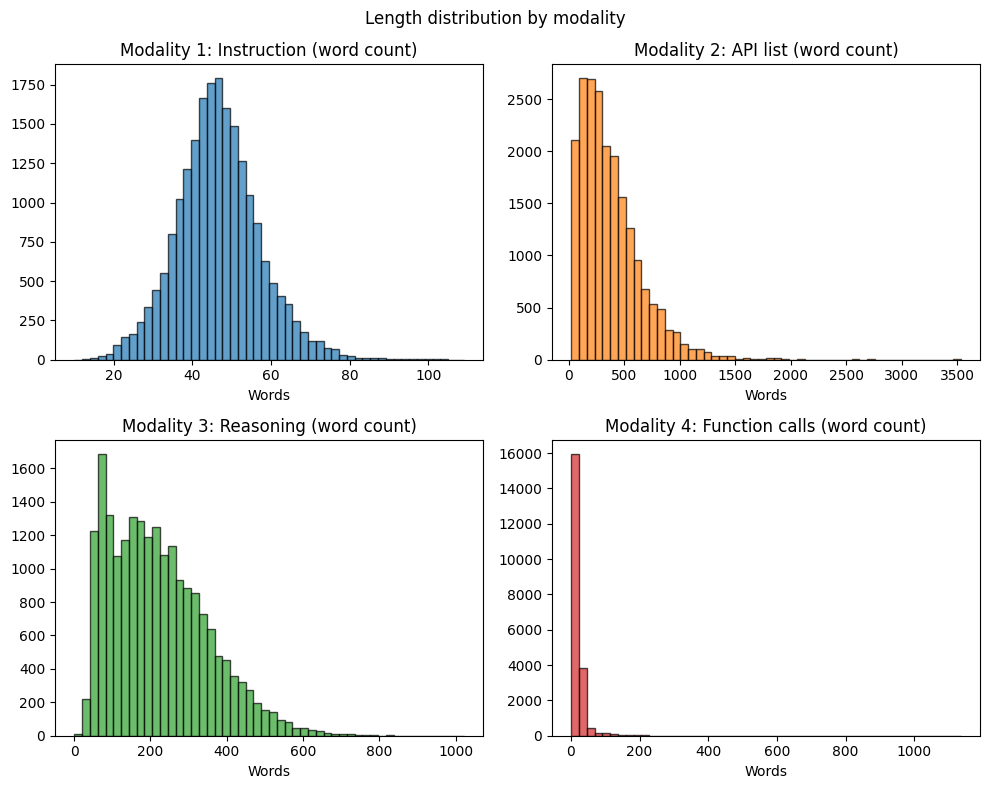

Mean word count per modality:
  Instruction: 46.5
  API list: 380.0
  Reasoning: 221.1
  Function calls: 19.6


In [5]:
# Use same df with four modalities (from cells above)
df = df_toolbench.copy()
df["instruction"] = df["instruction"].fillna("")
df["api_list_json"] = df["api_list_json"].fillna("[]")
df["reasoning_output"] = df["reasoning_output"].fillna("")
df["function_calls_json"] = df["function_calls_json"].fillna("[]")

# Length: word count per modality
df["instruction_len_word"] = df["instruction"].str.split().str.len()
df["api_list_len_word"] = df["api_list_json"].astype(str).str.split().str.len()
df["reasoning_len_word"] = df["reasoning_output"].str.split().str.len()
df["function_calls_len_word"] = df["function_calls_json"].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(df["instruction_len_word"], bins=50, edgecolor="black", alpha=0.7, color=MODALITY_COLORS[0])
axes[0, 0].set_title("Modality 1: Instruction (word count)")
axes[0, 0].set_xlabel("Words")
axes[0, 1].hist(df["api_list_len_word"], bins=50, edgecolor="black", alpha=0.7, color=MODALITY_COLORS[1])
axes[0, 1].set_title("Modality 2: API list (word count)")
axes[0, 1].set_xlabel("Words")
axes[1, 0].hist(df["reasoning_len_word"], bins=50, edgecolor="black", alpha=0.7, color=MODALITY_COLORS[2])
axes[1, 0].set_title("Modality 3: Reasoning (word count)")
axes[1, 0].set_xlabel("Words")
axes[1, 1].hist(df["function_calls_len_word"], bins=50, edgecolor="black", alpha=0.7, color=MODALITY_COLORS[3])
axes[1, 1].set_title("Modality 4: Function calls (word count)")
axes[1, 1].set_xlabel("Words")
plt.suptitle("Length distribution by modality")
plt.tight_layout()
plt.show()

print("Mean word count per modality:")
print("  Instruction:", df["instruction_len_word"].mean().round(1))
print("  API list:", df["api_list_len_word"].mean().round(1))
print("  Reasoning:", df["reasoning_len_word"].mean().round(1))
print("  Function calls:", df["function_calls_len_word"].mean().round(1))

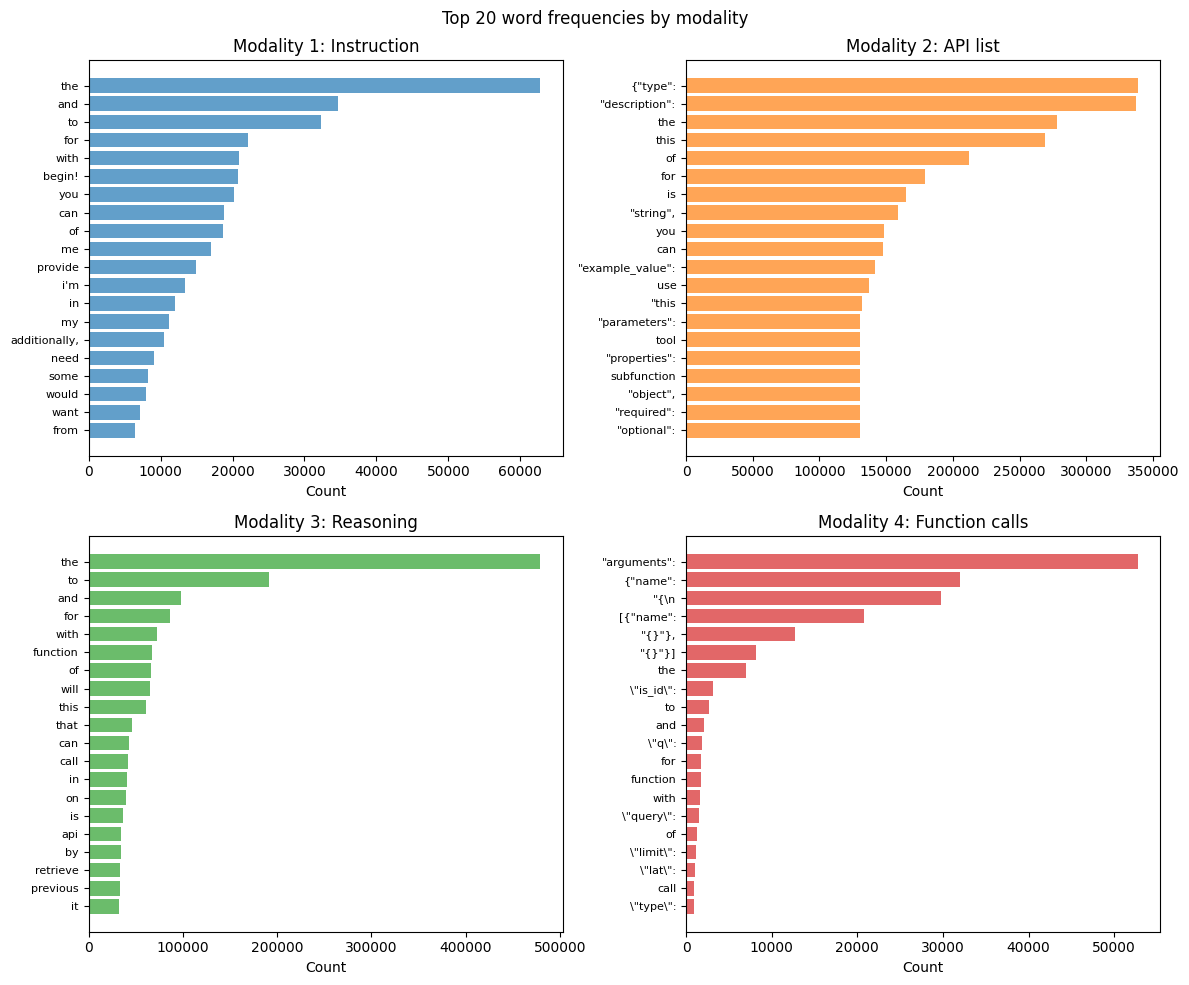

In [6]:
# Word frequency: top N words per modality (lowercased, skip very short tokens)
def get_top_words(series, top_n=20, min_len=2):
    all_words = []
    for text in series.astype(str):
        words = text.lower().split()
        all_words.extend(w for w in words if len(w) >= min_len)
    return Counter(all_words).most_common(top_n)

top_instruction = get_top_words(df["instruction"], top_n=20)
top_api = get_top_words(df["api_list_json"].astype(str), top_n=20)
top_reasoning = get_top_words(df["reasoning_output"], top_n=20)
top_function_calls = get_top_words(df["function_calls_json"].astype(str), top_n=20)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, data, mod_name, color in [
    (axes[0, 0], top_instruction, "Modality 1: Instruction", MODALITY_COLORS[0]),
    (axes[0, 1], top_api, "Modality 2: API list", MODALITY_COLORS[1]),
    (axes[1, 0], top_reasoning, "Modality 3: Reasoning", MODALITY_COLORS[2]),
    (axes[1, 1], top_function_calls, "Modality 4: Function calls", MODALITY_COLORS[3]),
]:
    if data:
        words, counts = zip(*data)
        ax.barh(range(len(words)), counts, alpha=0.7, color=color)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=8)
        ax.invert_yaxis()
    ax.set_title(mod_name)
    ax.set_xlabel("Count")
plt.suptitle("Top 20 word frequencies by modality")
plt.tight_layout()
plt.show()

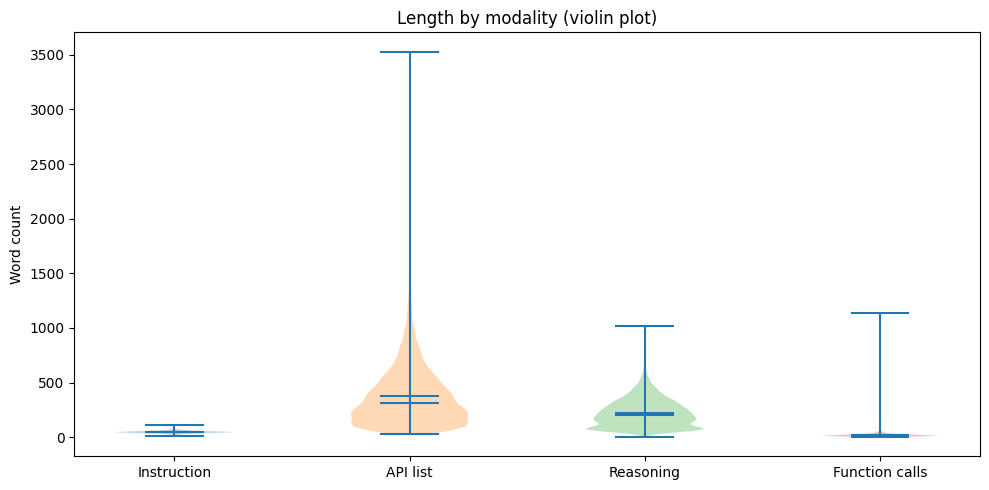

      Modality  Mean (words)  Median (words)
   Instruction          46.5            46.0
      API list         380.0           316.0
     Reasoning         221.1           202.0
Function calls          19.6            14.0


In [7]:
# Violin plot of word counts by modality (same colors as elsewhere)
lengths_df = pd.DataFrame({
    MODALITY_NAMES[0]: df["instruction_len_word"],
    MODALITY_NAMES[1]: df["api_list_len_word"],
    MODALITY_NAMES[2]: df["reasoning_len_word"],
    MODALITY_NAMES[3]: df["function_calls_len_word"],
})
fig, ax = plt.subplots(figsize=(10, 5))
data = [lengths_df[MODALITY_NAMES[i]] for i in range(4)]
vp = ax.violinplot(data, positions=range(4), showmeans=True, showmedians=True)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(MODALITY_COLORS[i])
ax.set_xticks(range(4))
ax.set_xticklabels(MODALITY_NAMES)
ax.set_ylabel("Word count")
ax.set_title("Length by modality (violin plot)")
plt.tight_layout()
plt.show()

# Summary table: mean and median word count per modality
summary = pd.DataFrame({
    "Modality": MODALITY_NAMES,
    "Mean (words)": [df["instruction_len_word"].mean(), df["api_list_len_word"].mean(),
                     df["reasoning_len_word"].mean(), df["function_calls_len_word"].mean()],
    "Median (words)": [df["instruction_len_word"].median(), df["api_list_len_word"].median(),
                       df["reasoning_len_word"].median(), df["function_calls_len_word"].median()],
}).round(1)
print(summary.to_string(index=False))

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1200.62it/s, Materializing param=transformer.wte.weight]            
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Instruction: perplexity = 68.18 ± 82.52 (2 std)
  API list: perplexity = 46.60 ± 0.00 (2 std)
  Reasoning: perplexity = 22.28 ± 24.78 (2 std)
  Function calls: perplexity = 31.84 ± 65.63 (2 std)


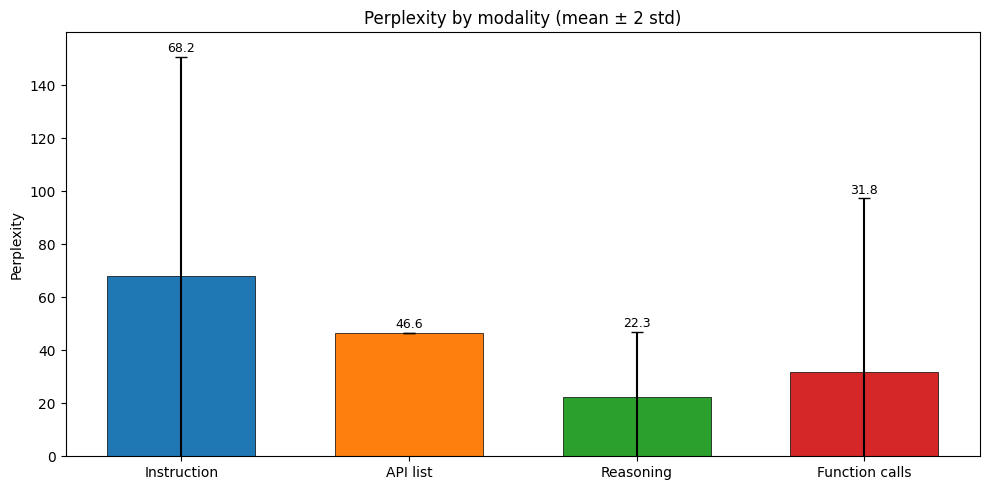

In [8]:
# Perplexity calculation per modality (using a pretrained LM)
def compute_perplexity_stats(text_series, model, tokenizer, device, max_length=256, max_samples=400):
    """Compute mean and std of perplexity over a sample of texts. Returns (mean_ppl, std_ppl)."""
    texts = text_series.dropna().replace("", np.nan).dropna().tolist()
    if not texts:
        return float("nan"), float("nan")
    texts = texts[:max_samples]
    per_text_ppl = []
    model.eval()
    with torch.no_grad():
        for text in texts:
            if not isinstance(text, str) or not text.strip():
                continue
            enc = tokenizer(text.strip(), return_tensors="pt", truncation=True, max_length=max_length)
            input_ids = enc.input_ids.to(device)
            if input_ids.size(1) < 2:
                continue
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss
            ppl = np.exp(loss.item())
            per_text_ppl.append(ppl)
    if not per_text_ppl:
        return float("nan"), float("nan")
    return np.mean(per_text_ppl), np.std(per_text_ppl)

# Ensure df exists and has text columns (use df from earlier cells; fallback to df_toolbench)
if "df" not in dir() and "df_toolbench" in dir():
    df = df_toolbench.copy()
    df["instruction"] = df["instruction"].fillna("")
    df["api_list_text"] = df.get("api_list_text", df.get("api_list_json", pd.Series([""] * len(df))).astype(str))
    df["reasoning_output"] = df["reasoning_output"].fillna("")
    df["function_calls_json"] = df["function_calls_json"].fillna("[]").astype(str)

perplexity = []
perplexity_std = []

from transformers import AutoModelForCausalLM, AutoTokenizer
MODEL_ID = "distilbert/distilgpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID)
model = model.to(device)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
modality_texts = [
    df["instruction"],
    df.get("api_list_text", df["api_list_json"].astype(str)),
    df["reasoning_output"],
    df["function_calls_json"].astype(str),
]
for i, name in enumerate(MODALITY_NAMES):
    mean_ppl, std_ppl = compute_perplexity_stats(modality_texts[i], model, tokenizer, device)
    perplexity.append(mean_ppl)
    perplexity_std.append(std_ppl if not np.isnan(std_ppl) else 0.0)
    print(f"  {name}: perplexity = {mean_ppl:.2f} ± {2*perplexity_std[-1]:.2f} (2 std)")

x = np.arange(len(MODALITY_NAMES))
width = 0.65
yerr = np.array(perplexity_std) * 2

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x, perplexity, width, color=MODALITY_COLORS, edgecolor="black", linewidth=0.5, yerr=yerr, capsize=4)

for i, (bar, ppl) in enumerate(zip(bars1, perplexity)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (yerr[i] if i < len(yerr) else 0) + 0.5,
            f"{ppl:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Perplexity")
ax.set_title("Perplexity by modality (mean ± 2 std)")
ax.set_xticks(x)
ax.set_xticklabels(MODALITY_NAMES, ha="center")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [ ]:
import json
import re
from typing import List, Dict, Any, Union

class ToolBenchEvaluator:
    def __init__(self):
        """
        Initialize the evaluator.
        """
        pass

    def parse_prediction(self, prediction: str) -> Union[Dict, None]:
        """
        Helper to safely parse model output into a dictionary.
        Returns None if parsing fails.
        """
        try:
            # Attempt standard JSON parse
            return json.loads(prediction)
        except json.JSONDecodeError:
            # Fallback: Attempt to fix common single-quote issues or trailing commas
            # (Specialized regex parsing can be added here if needed)
            try:
                # Basic cleanup for common LLM mistakes
                fixed_pred = prediction.replace("'", '"')
                return json.loads(fixed_pred)
            except:
                return None

    def calculate_json_validity(self, predictions: List[str]) -> float:
        """
        Metric 4: JSON Syntax Validity
        The percentage of outputs that can be successfully parsed.
        """
        if not predictions: return 0.0

        valid_count = 0
        for pred in predictions:
            if self.parse_prediction(pred) is not None:
                valid_count += 1

        return valid_count / len(predictions)

    def calculate_success_rate(self, predictions: List[str], ground_truths: List[Dict]) -> float:
        """
        Metric 1: Success Rate (Pass Rate)
        Percentage of test cases where the model selects the correct API function name.
        """
        if not predictions: return 0.0

        match_count = 0
        for pred_str, gt in zip(predictions, ground_truths):
            pred_obj = self.parse_prediction(pred_str)

            # If parsing failed, it's automatically a fail for function selection
            if pred_obj and pred_obj.get("name") == gt.get("name"):
                match_count += 1

        return match_count / len(predictions)

    def calculate_argument_match_rate(self, predictions: List[str], ground_truths: List[Dict]) -> float:
        """
        Metric 2: Argument Match Rate
        For correctly selected functions, what percentage of arguments exactly match?

        Note: This is calculated ONLY on instances where the function name was correct.
        """
        correct_func_instances = 0
        total_arg_accuracy = 0.0

        for pred_str, gt in zip(predictions, ground_truths):
            pred_obj = self.parse_prediction(pred_str)

            # Only evaluate argument if function name is correct
            if pred_obj and pred_obj.get("name") == gt.get("name"):
                correct_func_instances += 1

                gt_args = gt.get("arguments", {})
                pred_args = pred_obj.get("arguments", {})

                # Edge Case: Function takes no args
                if not gt_args:
                    # If GT has no args, 100% match if Pred also has no args, else 0%
                    total_arg_accuracy += 1.0 if not pred_args else 0.0
                    continue

                # Count matches
                matches = 0
                for key, val in gt_args.items():
                    # We cast to str to handle "10" vs 10 mismatches
                    if key in pred_args and str(pred_args[key]) == str(val):
                        matches += 1

                # Instance score is matches / total expected args
                total_arg_accuracy += matches / len(gt_args)

        if correct_func_instances == 0:
            return 0.0

        return total_arg_accuracy / correct_func_instances

    def calculate_hallucination_rate(self, predictions: List[str], valid_schemas: List[Dict]) -> float:
        """
        Metric 3: Hallucination Rate
        Frequency of predictions containing non-existent function names or parameters.

        valid_schemas: A list of dicts defining valid tools for EACH prediction context.
                       Format: {"valid_tools": {"tool_name": ["param1", "param2"]}}
        """
        if not predictions: return 0.0

        hallucination_count = 0

        for pred_str, schema_context in zip(predictions, valid_schemas):
            pred_obj = self.parse_prediction(pred_str)

            # If we can't parse it, we usually count it as syntax error, NOT hallucination.
            # Here we skip unparsable to keep metrics orthogonal.
            if not pred_obj:
                continue

            pred_name = pred_obj.get("name")
            pred_args = pred_obj.get("arguments", {})
            valid_tools = schema_context.get("valid_tools", {}) # Dict of ToolName -> List[Params]

            # Check 1: Function Hallucination
            if pred_name not in valid_tools:
                hallucination_count += 1
                continue # Stop checking args if function is fake

            # Check 2: Parameter Hallucination
            # Are there keys in prediction that don't exist in the definition?
            allowed_params = valid_tools[pred_name]
            is_param_hallucinated = False
            for param in pred_args.keys():
                if param not in allowed_params:
                    is_param_hallucinated = True
                    break

            if is_param_hallucinated:
                hallucination_count += 1

        return hallucination_count / len(predictions)

# ==========================================
# Example Usage
# ==========================================

evaluator = ToolBenchEvaluator()

# Mock Data
preds = [
    '{"name": "search_tool", "arguments": {"query": "Boston weather"}}',  # Perfect
    '{"name": "search_tool", "arguments": {"query": "NYC weather", "fake_param": 1}}', # Arg Mismatch + Param Hallucination
    '{"name": "wrong_tool", "arguments": {}}', # Wrong Name
    'Broken JSON :::' # Syntax Error
]

gts = [
    {"name": "search_tool", "arguments": {"query": "Boston weather"}},
    {"name": "search_tool", "arguments": {"query": "NYC weather"}},
    {"name": "calc_tool", "arguments": {}},
    {"name": "search_tool", "arguments": {"query": "test"}}
]

# Schemas corresponding to each query
schemas = [
    {"valid_tools": {"search_tool": ["query"], "calc_tool": []}} for _ in range(4)
]

syntax_score = evaluator.calculate_json_validity(preds)
success_score = evaluator.calculate_success_rate(preds, gts)
arg_match_score = evaluator.calculate_argument_match_rate(preds, gts)
halluc_score = evaluator.calculate_hallucination_rate(preds, schemas)

print(f"JSON Syntax Validity: {syntax_score:.2%} (Expected: 75%)")
print(f"Success Rate:         {success_score:.2%} (Expected: 50%)")
print(f"Argument Match Rate:  {arg_match_score:.2%} (Expected: 100%)")
print(f"Hallucination Rate:   {halluc_score:.2%} (Expected: 50%)")

JSON Syntax Validity: 75.00% (Expected: 75%)
Success Rate:         50.00% (Expected: 50%)
Argument Match Rate:  100.00% (Expected: 100%)
Hallucination Rate:   50.00% (Expected: 50%)


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [10]:
# BONUS CODE HERE

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!